# Representational bias study — COMPAS (race)

Real-data counterpart to the synthetic `repr_*` track in `benchmark/biasondemand/`.
Build a perfectly balanced base on COMPAS (25/25/25/25 across `(race, Y)`), then
progressively shrink the two unprivileged cells while keeping the privileged cells
fixed. Within-group `P(Y=1) = 0.5` is held constant in *both* groups — only group
**size** changes — so any fairness movement is attributable to pure representational
bias and not to label drift.

Sensitive attribute: `race` (1 = Caucasian = privileged, 0 = non-Caucasian = unprivileged) —
the canonical ProPublica setup. The limiting cell is expected to be `(race=1, Y=1)` —
Caucasians who recidivated — at ≈ 950 rows, giving a base N ≈ 3800.

**Small-sample caveat:** at `p_u=0.1` each unprivileged cell has ~95 rows, ~19 per
held-out fold under 5-fold CV. Tight but feasible. If fairness-vs-`p_u` curves look
jagged at the tail, rerun with `n_repeats=3` (3× runtime) or trim the sweep at `p_u=0.25`.

## 1. Define the sweep grid

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import yaml

from skfair.datasets import load_compas

DATASET_NAME = "compas"
SENS_ATTR = "race"
PRIV_GROUP = 1
BASE_SEED = 42

P_U_LEVELS = [1.0, 0.75, 0.5, 0.25, 0.1]

DATA_DIR = Path("datasets") / DATASET_NAME
OUT_DIR = Path("../outputs/representational_study")
DATA_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

force = False

## 2. Build the balanced 25/25/25/25 base

Compute the four `(race, Y)` cell counts, pick the smallest as `n_per_cell`, and
random-sample that many rows from each cell with `random_state=BASE_SEED`. The
result is a balanced base where `P(race=1) = P(Y=1) = P(Y=1|race=0) = P(Y=1|race=1) = 0.5`
— no historical bias, no representational bias, the reference point.

In [2]:
X_full, y_full = load_compas()
df_full = X_full.copy()
df_full["Y"] = np.asarray(y_full).astype(int)

cells = {(a, y): df_full[(df_full[SENS_ATTR] == a) & (df_full["Y"] == y)]
         for a in (0, 1) for y in (0, 1)}

print("(race, Y) cell counts:")
for k, v in cells.items():
    print(f"  {k}: {len(v)}")

n_per_cell = min(len(v) for v in cells.values())
print(f"\nlimiting cell -> n_per_cell = {n_per_cell}")

rng = np.random.RandomState(BASE_SEED)
base = pd.concat(
    [df.sample(n=n_per_cell, random_state=rng.randint(0, 2**31 - 1))
     for df in cells.values()],
    ignore_index=True,
)

assert (base.groupby([SENS_ATTR, "Y"]).size() == n_per_cell).all(), \
    "balanced base must have exactly n_per_cell rows in every (race, Y) cell"
print(f"\nbase shape: {base.shape}  (4 × {n_per_cell} = {4 * n_per_cell})")

(race, Y) cell counts:
  (0, 0): 2475
  (0, 1): 2285
  (1, 0): 1488
  (1, 1): 966

limiting cell -> n_per_cell = 966

base shape: (3864, 9)  (4 × 966 = 3864)


## 3. Generate the 5 level CSVs

For each `p_u`, keep both privileged cells at full `n_per_cell` and randomly
downsample each unprivileged cell to `int(n_per_cell * p_u)` rows. Per-level
seed = `BASE_SEED + i` so the sweep is fully deterministic and reproducible.
Idempotent: skipped if the CSV already exists (`force=True` regenerates).

In [3]:
priv_rows = base[base[SENS_ATTR] == PRIV_GROUP]
unpriv_rows = base[base[SENS_ATTR] != PRIV_GROUP]

for i, p_u in enumerate(P_U_LEVELS):
    tag = f"{int(p_u * 100):03d}"
    out = DATA_DIR / f"{DATASET_NAME}_p_u_{tag}.csv"
    if out.exists() and not force:
        print(f"skip {out.name} (exists)")
        continue

    k = int(n_per_cell * p_u)
    rng_lvl = np.random.RandomState(BASE_SEED + i)
    unpriv_kept = pd.concat(
        [g.sample(n=k, random_state=rng_lvl.randint(0, 2**31 - 1))
         for _, g in unpriv_rows.groupby("Y", sort=True)],
        ignore_index=True,
    )
    level = pd.concat([priv_rows, unpriv_kept], ignore_index=True)

    counts = level.groupby([SENS_ATTR, "Y"]).size().to_dict()
    assert counts[(PRIV_GROUP, 0)] == n_per_cell
    assert counts[(PRIV_GROUP, 1)] == n_per_cell
    assert counts[(1 - PRIV_GROUP, 0)] == k
    assert counts[(1 - PRIV_GROUP, 1)] == k

    level.to_csv(out, index=False)
    print(f"wrote {out.name}  shape={level.shape}  unpriv_per_cell={k}")

skip compas_p_u_100.csv (exists)
skip compas_p_u_075.csv (exists)
skip compas_p_u_050.csv (exists)
skip compas_p_u_025.csv (exists)
skip compas_p_u_010.csv (exists)


## 4. Load each level into the custom-dataset shape

`Experiment` accepts a list of dicts of the form
`{"name", "data": (X, y), "sens_attr", "priv_group"}`.

In [4]:
def load_level(csv_path, name):
    df = pd.read_csv(csv_path)
    y = df["Y"].astype(int)
    X = df.drop(columns=["Y"])
    return {"name": name, "data": (X, y), "sens_attr": SENS_ATTR, "priv_group": PRIV_GROUP}

datasets = [
    load_level(DATA_DIR / f"{DATASET_NAME}_p_u_{int(p * 100):03d}.csv",
               f"{DATASET_NAME}_p_u_{int(p * 100):03d}")
    for p in P_U_LEVELS
]
[(d["name"], d["data"][0].shape, int(d["data"][1].sum())) for d in datasets]

[('compas_p_u_100', (3864, 8), 1932),
 ('compas_p_u_075', (3380, 8), 1690),
 ('compas_p_u_050', (2898, 8), 1449),
 ('compas_p_u_025', (2414, 8), 1207),
 ('compas_p_u_010', (2124, 8), 1062)]

## 5. Build the Experiment

Methods / classifiers / metrics / CV come straight from `config.yaml`
(identical to `biasondemand` and `adult.ipynb`).

In [5]:
from skfair.experimentation import Experiment

with open("config.yaml") as f:
    cfg = yaml.safe_load(f)

exp = Experiment(
    datasets=datasets,
    methods=cfg["methods"],
    classifiers=cfg["classifiers"],
    metrics=cfg["metrics"],
    n_splits=cfg["cv"]["n_splits"],
    random_state=cfg["cv"]["random_state"],
    stratify=cfg["cv"].get("stratify", "y"),
    audit_bias=cfg["audit"]["bias"],
    audit_fairness=cfg["audit"]["fairness"],
    save_results_csv=cfg["save"]["results_csv"],
    save_object_pkl=cfg["save"]["object_pkl"],
    save_report_html=cfg["save"]["report_html"],
    save_path=str(OUT_DIR / DATASET_NAME),
)

## 6. Run

5 datasets × 12 methods × 4 classifiers × 5 folds = **1200 fits**. Outputs
land in `../outputs/representational_study/compas.{csv,pkl,html}`.

In [6]:
results = exp.run(verbose=True)
results


Dataset: compas_p_u_100


  Baseline                       | LogReg  acc=0.659  spd=-0.068
  Baseline                       | DecisionTree  acc=0.585  spd=0.008


  Baseline                       | SVC  acc=0.661  spd=0.081


  Baseline                       | XGBoost  acc=0.634  spd=-0.018


  FairSmote                      | LogReg  acc=0.660  spd=-0.069
  FairSmote                      | DecisionTree  acc=0.586  spd=0.007


...

  FairMask                       | LogReg  acc=0.639  spd=0.108


  FairMask                       | DecisionTree  acc=0.549  spd=0.078


  FairMask                       | SVC  acc=0.636  spd=0.141


  FairMask                       | XGBoost  acc=0.606  spd=0.112


,dataset,method,classifier,accuracy,balanced_accuracy,precision,recall,f1_score,disparate_impact,spd,eod,aod,true_negative_rate_difference,predictive_equality,accuracy_parity,equal_opportunity_ratio,false_negative_rate_difference
0,compas_p_u_100,Baseline,LogReg,0.659420,0.659446,0.669056,0.631496,0.649165,0.863887,-0.068352,-0.028951,-0.068322,0.107692,0.707125,1.062499,0.955321,0.028951
1,compas_p_u_100,Baseline,DecisionTree,0.584626,0.584638,0.598894,0.514489,0.553043,1.021975,0.007733,0.033150,0.007743,0.017665,0.961386,1.045868,1.069676,-0.033150
2,compas_p_u_100,Baseline,SVC,0.660710,0.660748,0.679931,0.609243,0.641103,1.202563,0.081215,0.112836,0.081251,-0.049666,1.190739,1.049903,1.210820,-0.112836
3,compas_p_u_100,Baseline,XGBoost,0.633795,0.633828,0.642176,0.604587,0.622225,0.964985,-0.018124,0.016612,-0.018087,0.052786,0.860022,1.056757,1.029603,-0.016612
4,compas_p_u_100,FairSmote,LogReg,0.659937,0.659964,0.669850,0.631496,0.649514,0.861809,-0.069389,-0.028951,-0.069358,0.109764,0.701242,1.064103,0.955321,0.028951
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,compas_p_u_010,FairBalanceClassifier,XGBoost,0.586632,0.586671,0.590047,0.570644,0.579001,0.988252,-0.004571,0.061643,-0.004193,0.070028,0.818561,1.111454,1.108139,-0.061643
236,compas_p_u_010,FairMask,LogReg,0.639347,0.639428,0.693224,0.503818,0.581098,1.298539,0.108447,0.145068,0.108328,-0.071588,1.295164,1.057473,1.297031,-0.145068
237,compas_p_u_010,FairMask,DecisionTree,0.548968,0.549001,0.558839,0.468049,0.508808,1.195792,0.077872,0.059331,0.079029,-0.098727,1.297205,0.963716,1.127817,-0.059331
238,compas_p_u_010,FairMask,SVC,0.636048,0.636086,0.663126,0.554602,0.601182,1.348590,0.140902,0.169633,0.140786,-0.111939,1.401893,1.045716,1.323097,-0.169633


## 7. Summary tables

In [7]:
report = exp.to_report()
tables = report.summary_tables()
for name, df in tables.items():
    print(f"--- {name} ---")
    display(df)

--- compas_p_u_010 ---


,accuracy,balanced_accuracy,precision,recall,f1_score,disparate_impact,spd,eod,aod,true_negative_rate_difference,predictive_equality,accuracy_parity,equal_opportunity_ratio,false_negative_rate_difference
method,,,,,,,,,,,,,,
Baseline,0.6135,0.6135,0.6230,0.5732,0.5954,1.0990,0.0428,0.0522,0.0432,-0.0342,1.1102,1.0127,1.0914,-0.0522
DisparateImpactRemover,0.6111,0.6111,0.6233,0.5645,0.5907,1.1447,0.0588,0.0509,0.0591,-0.0672,1.2256,0.9850,1.1000,-0.0509
FAWOS,0.6139,0.6140,0.6236,0.5732,0.5957,1.1000,0.0434,0.0522,0.0437,-0.0352,1.1124,1.0119,1.0914,-0.0522
FairBalanceClassifier,0.6088,0.6088,0.6177,0.5739,0.5931,1.0310,0.0111,0.0145,0.0116,-0.0087,1.0427,1.0036,1.0269,-0.0145
FairMask,0.6076,0.6076,0.6332,0.5207,0.5690,1.2739,0.1098,0.1298,0.1101,-0.0905,1.3076,1.0301,1.2532,-0.1298
FairOversampling,0.6113,0.6114,0.6212,0.5702,0.5929,1.0895,0.0382,0.0470,0.0385,-0.0300,1.1007,1.0124,1.0830,-0.0470
FairSmote,0.6120,0.6121,0.6191,0.5841,0.5999,1.0620,0.0266,0.0376,0.0268,-0.0160,1.0540,1.0179,1.0705,-0.0376
FairwayRemover,0.6065,0.6065,0.6223,0.5438,0.5789,1.0489,0.0159,0.0416,0.0161,0.0094,0.9984,1.0419,1.0847,-0.0416
HeterogeneousFOS,0.6156,0.6156,0.6260,0.5735,0.5972,1.0933,0.0408,0.0470,0.0413,-0.0357,1.1141,1.0078,1.0843,-0.0470


--- compas_p_u_025 ---


,accuracy,balanced_accuracy,precision,recall,f1_score,disparate_impact,spd,eod,aod,true_negative_rate_difference,predictive_equality,accuracy_parity,equal_opportunity_ratio,false_negative_rate_difference
method,,,,,,,,,,,,,,
Baseline,0.6197,0.6197,0.6287,0.5818,0.6032,1.0333,0.0091,0.0378,0.0092,0.0194,0.9648,1.0451,1.0729,-0.0378
DisparateImpactRemover,0.6190,0.6190,0.6307,0.5760,0.6007,1.0567,0.0199,0.0450,0.0200,0.0051,1.0091,1.0396,1.0838,-0.0450
FAWOS,0.6201,0.6201,0.6295,0.5812,0.6032,1.0304,0.0078,0.0373,0.0079,0.0215,0.9585,1.0464,1.0720,-0.0373
FairBalanceClassifier,0.6187,0.6187,0.6283,0.5839,0.6037,1.0273,0.0065,0.0326,0.0066,0.0194,0.9693,1.0412,1.0627,-0.0326
FairMask,0.6114,0.6114,0.6363,0.5274,0.5754,1.2588,0.0966,0.1148,0.0967,-0.0785,1.3114,1.0274,1.2279,-0.1148
FairOversampling,0.6218,0.6218,0.6320,0.5804,0.6040,1.0347,0.0096,0.0383,0.0097,0.0189,0.9697,1.0456,1.0741,-0.0383
FairSmote,0.6241,0.6241,0.6366,0.5771,0.6042,1.0505,0.0166,0.0347,0.0168,0.0012,1.0200,1.0274,1.0652,-0.0347
FairwayRemover,0.6146,0.6146,0.6291,0.5580,0.5903,1.0864,0.0318,0.0557,0.0318,-0.0079,1.0443,1.0365,1.1056,-0.0557
HeterogeneousFOS,0.6165,0.6165,0.6269,0.5737,0.5980,1.0617,0.0197,0.0414,0.0198,0.0019,1.0311,1.0344,1.0807,-0.0414


--- compas_p_u_050 ---


,accuracy,balanced_accuracy,precision,recall,f1_score,disparate_impact,spd,eod,aod,true_negative_rate_difference,predictive_equality,accuracy_parity,equal_opportunity_ratio,false_negative_rate_difference
method,,,,,,,,,,,,,,
Baseline,0.6278,0.6279,0.6409,0.5804,0.6085,1.0027,-0.0045,0.0426,-0.0045,0.0515,0.8658,1.0772,1.0868,-0.0426
DisparateImpactRemover,0.6276,0.6276,0.6412,0.5801,0.6083,1.0261,0.0069,0.0400,0.0069,0.0262,0.9337,1.0542,1.0818,-0.0400
FAWOS,0.6282,0.6282,0.6415,0.5802,0.6086,1.0041,-0.0038,0.0436,-0.0037,0.0510,0.8660,1.0776,1.0887,-0.0436
FairBalanceClassifier,0.6295,0.6295,0.6421,0.5880,0.6131,1.0096,-0.0014,0.0459,-0.0014,0.0486,0.8759,1.0776,1.0920,-0.0459
FairMask,0.6217,0.6217,0.6471,0.5425,0.5889,1.2559,0.0944,0.1337,0.0945,-0.0553,1.2266,1.0641,1.2771,-0.1337
FairOversampling,0.6291,0.6291,0.6423,0.5821,0.6100,1.0101,-0.0013,0.0470,-0.0012,0.0495,0.8709,1.0789,1.0948,-0.0470
FairSmote,0.6272,0.6272,0.6388,0.5858,0.6104,1.0095,-0.0023,0.0268,-0.0023,0.0314,0.9300,1.0473,1.0582,-0.0268
FairwayRemover,0.6265,0.6265,0.6441,0.5663,0.6017,1.0069,-0.0048,0.0420,-0.0048,0.0516,0.8814,1.0772,1.0881,-0.0420
HeterogeneousFOS,0.6297,0.6297,0.6425,0.5863,0.6125,1.0353,0.0097,0.0501,0.0097,0.0306,0.9271,1.0672,1.1034,-0.0501


--- compas_p_u_075 ---


,accuracy,balanced_accuracy,precision,recall,f1_score,disparate_impact,spd,eod,aod,true_negative_rate_difference,predictive_equality,accuracy_parity,equal_opportunity_ratio,false_negative_rate_difference
method,,,,,,,,,,,,,,
Baseline,0.6268,0.6269,0.6393,0.5809,0.6082,1.0051,-0.0051,0.0149,-0.0051,0.0252,0.9540,1.0330,1.0377,-0.0149
DisparateImpactRemover,0.6228,0.6228,0.6337,0.5811,0.6054,1.0489,0.0168,0.0364,0.0168,0.0028,1.0093,1.0325,1.0746,-0.0364
FAWOS,0.6268,0.6269,0.6393,0.5809,0.6082,1.0051,-0.0051,0.0149,-0.0051,0.0252,0.9540,1.0330,1.0377,-0.0149
FairBalanceClassifier,0.6224,0.6224,0.6338,0.5819,0.6062,1.0004,-0.0071,0.0126,-0.0071,0.0268,0.9525,1.0332,1.0334,-0.0126
FairMask,0.6183,0.6184,0.6396,0.5457,0.5883,1.2950,0.1087,0.1242,0.1087,-0.0931,1.3752,1.0259,1.2595,-0.1242
FairOversampling,0.6263,0.6263,0.6387,0.5802,0.6076,1.0051,-0.0050,0.0138,-0.0050,0.0239,0.9573,1.0311,1.0359,-0.0138
FairSmote,0.6211,0.6211,0.6344,0.5703,0.6001,1.0054,-0.0050,0.0124,-0.0050,0.0224,0.9614,1.0283,1.0328,-0.0124
FairwayRemover,0.6171,0.6171,0.6310,0.5642,0.5951,0.9996,-0.0074,0.0152,-0.0075,0.0301,0.9389,1.0376,1.0383,-0.0152
HeterogeneousFOS,0.6230,0.6230,0.6347,0.5794,0.6051,1.0196,0.0013,0.0187,0.0013,0.0161,0.9800,1.0288,1.0459,-0.0187


--- compas_p_u_100 ---


,accuracy,balanced_accuracy,precision,recall,f1_score,disparate_impact,spd,eod,aod,true_negative_rate_difference,predictive_equality,accuracy_parity,equal_opportunity_ratio,false_negative_rate_difference
method,,,,,,,,,,,,,,
Baseline,0.6346,0.6347,0.6475,0.5900,0.6164,1.0134,0.0006,0.0334,0.0006,0.0321,0.9298,1.0538,1.0664,-0.0334
DisparateImpactRemover,0.6285,0.6285,0.6411,0.5840,0.6100,1.0317,0.0116,0.0412,0.0117,0.0179,0.9560,1.0486,1.0783,-0.0412
FAWOS,0.6350,0.6350,0.6481,0.5897,0.6165,1.0120,-0.0000,0.0339,-0.0000,0.0339,0.9252,1.0557,1.0671,-0.0339
FairBalanceClassifier,0.6339,0.6339,0.6450,0.5958,0.6185,0.9951,-0.0099,0.0223,-0.0098,0.0420,0.9145,1.0527,1.0473,-0.0223
FairMask,0.6265,0.6265,0.6453,0.5652,0.6014,1.3043,0.1129,0.1434,0.1129,-0.0825,1.3417,1.0508,1.2960,-0.1434
FairOversampling,0.6327,0.6327,0.6455,0.5880,0.6144,1.0079,-0.0017,0.0285,-0.0017,0.0319,0.9304,1.0493,1.0569,-0.0285
FairSmote,0.6341,0.6341,0.6474,0.5880,0.6152,1.0168,0.0018,0.0357,0.0018,0.0321,0.9330,1.0557,1.0706,-0.0357
FairwayRemover,0.6300,0.6300,0.6444,0.5810,0.6096,1.0214,0.0022,0.0378,0.0022,0.0334,0.9266,1.0592,1.0826,-0.0378
HeterogeneousFOS,0.6336,0.6336,0.6464,0.5890,0.6154,1.0098,-0.0012,0.0301,-0.0012,0.0324,0.9325,1.0512,1.0598,-0.0301


## 8. Trade-off and ranking plots

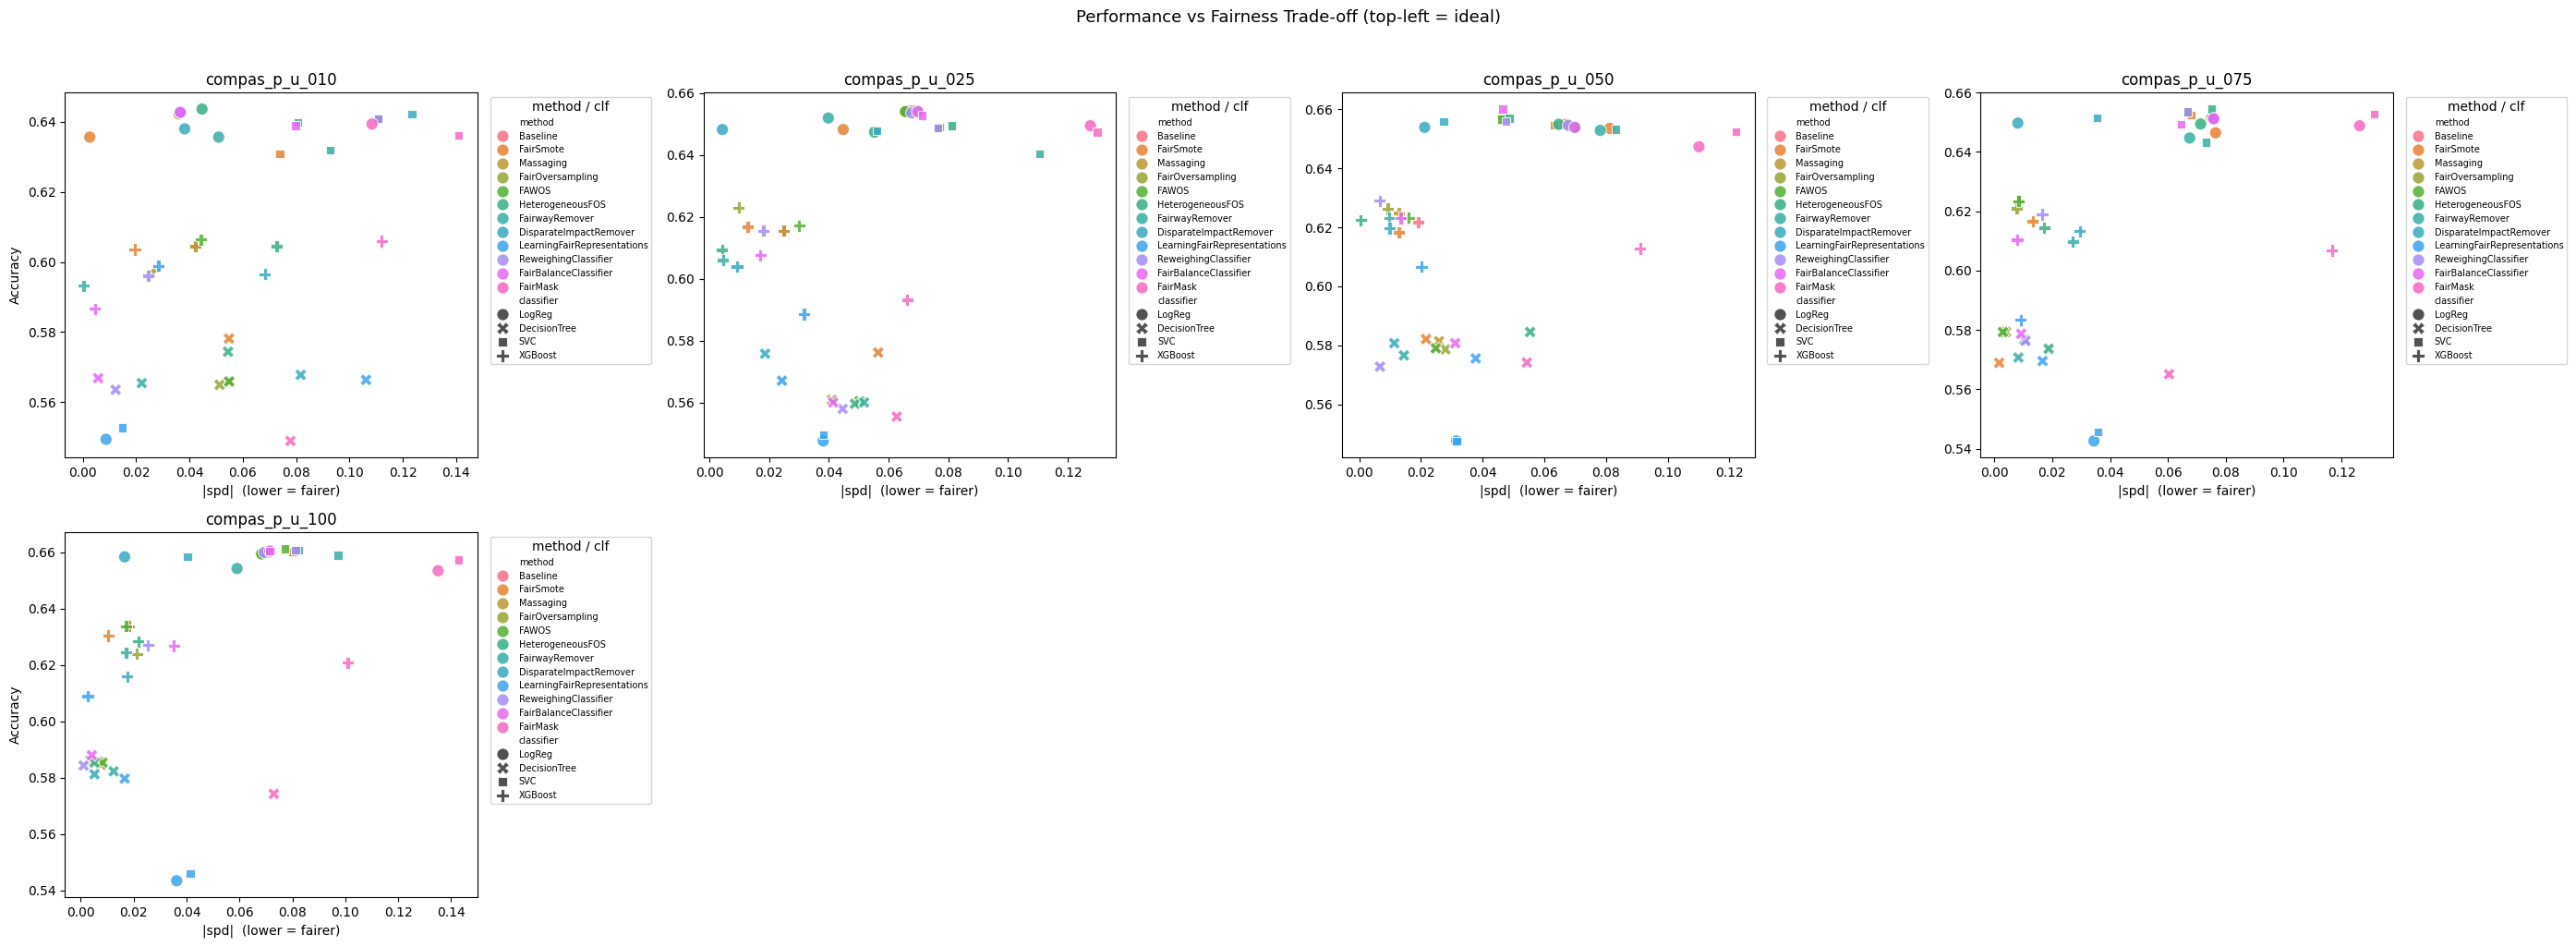

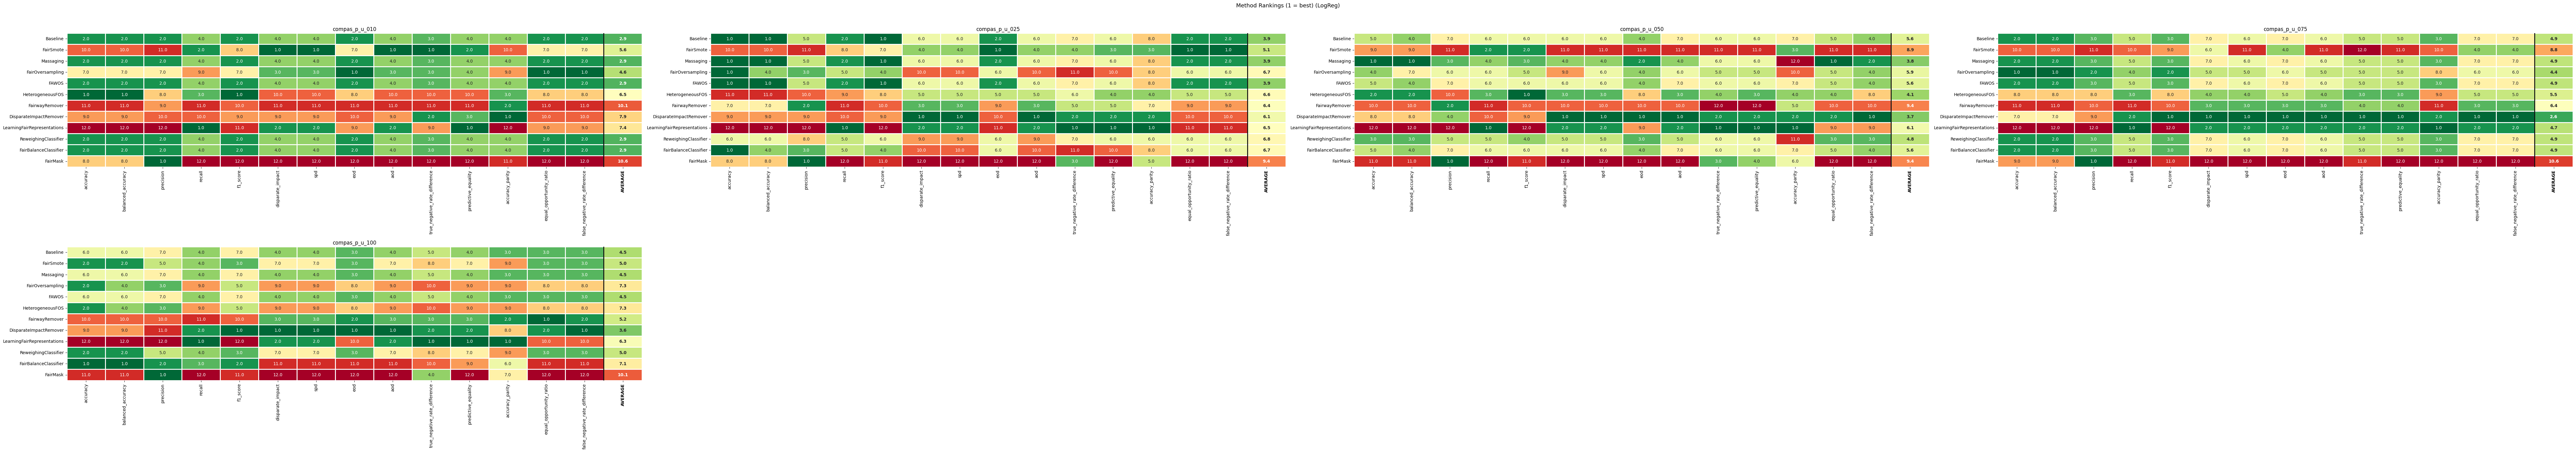

In [8]:
report.plot_tradeoff(fairness_metric="spd", performance_metric="accuracy");
report.plot_ranking(classifier="LogReg");

## 9. Headline view — fairness vs `p_u`

Parse `p_u` from the dataset name, then aggregate per (method, level). This is
the money chart: which methods hold fairness as the unprivileged group shrinks?
`Baseline` should worsen monotonically as `p_u` drops; preprocessing methods
that earn their keep should stay flatter.

In [9]:
df = results.copy()
df["p_u"] = df["dataset"].str.split("_p_u_").str[-1].astype(int) / 100

df.groupby(["method", "p_u"])[["spd", "disparate_impact", "eod", "accuracy"]].mean().round(3)

spd  disparate_impact    eod  accuracy
method                      p_u                                           
Baseline                    0.10  0.043             1.099  0.052     0.613
                            0.25  0.009             1.033  0.038     0.620
                            0.50 -0.005             1.003  0.043     0.628
                            0.75 -0.005             1.005  0.015     0.627
                            1.00  0.001             1.013  0.033     0.635
DisparateImpactRemover      0.10  0.059             1.145  0.051     0.611
                            0.25  0.020             1.057  0.045     0.619
                            0.50  0.007             1.026  0.040     0.628
                            0.75  0.017             1.049  0.036     0.623
                            1.00  0.012             1.032  0.041     0.628
FAWOS                       0.10  0.043             1.100  0.052     0.614
                            0.25  0.008             1.030  0.037     0.620
                            0.50 -0.004             1.004  0.044     0.628
                            0.75 -0.005             1.005  0.015     0.627
                            1.00 -0.000             1.012  0.034     0.635
FairBalanceClassifier       0.10  0.011             1.031  0.015     0.609
                            0.25  0.006             1.027  0.033     0.619
                            0.50 -0.001             1.010  0.046     0.629
                            0.75 -0.007             1.000  0.013     0.622
                            1.00 -0.010             0.995  0.022     0.634
FairMask                    0.10  0.110             1.274  0.130     0.608
                            0.25  0.097             1.259  0.115     0.611
                            0.50  0.094             1.256  0.134     0.622
                            0.75  0.109             1.295  0.124     0.618
                            1.00  0.113             1.304  0.143     0.626
FairOversampling            0.10  0.038             1.090  0.047     0.611
                            0.25  0.010             1.035  0.038     0.622
                            0.50 -0.001             1.010  0.047     0.629
                            0.75 -0.005             1.005  0.014     0.626
                            1.00 -0.002             1.008  0.029     0.633
FairSmote                   0.10  0.027             1.062  0.038     0.612
                            0.25  0.017             1.051  0.035     0.624
                            0.50 -0.002             1.009  0.027     0.627
                            0.75 -0.005             1.005  0.012     0.621
                            1.00  0.002             1.017  0.036     0.634
FairwayRemover              0.10  0.016             1.049  0.042     0.607
                            0.25  0.032             1.086  0.056     0.615
                            0.50 -0.005             1.007  0.042     0.626
                            0.75 -0.007             1.000  0.015     0.617
                            1.00  0.002             1.021  0.038     0.630
HeterogeneousFOS            0.10  0.041             1.093  0.047     0.616
                            0.25  0.020             1.062  0.041     0.616
                            0.50  0.010             1.035  0.050     0.630
                            0.75  0.001             1.020  0.019     0.623
                            1.00 -0.001             1.010  0.030     0.634
LearningFairRepresentations 0.10  0.035             1.080  0.051     0.567
                            0.25  0.033             1.066  0.036     0.563
                            0.50  0.030             1.062  0.052     0.569
                            0.75  0.019             1.036  0.015     0.560
                            1.00  0.016             1.025  0.023     0.570
Massaging                   0.10  0.043             1.099  0.052     0.613
                            0.25  0.009             1.033  0.